# Tropical Cyclone Energy Prediction — North Indian Ocean (ANN)

**Paper:** Beniwal, K. & Kumar, V. (2026). *The tropical cyclone energy prediction of the North Indian Ocean in monsoon using artificial neural networks.* MAUSAM, 77(2), 517–526.

This notebook reproduces the full workflow:
1. Load & inspect the IMD cyclone dataset (1982–2023).
2. Train an initial ANN on all 6 features.
3. Compute permutation feature importance.
4. Retrain an optimised ANN on the top features.
5. Compare the two models against linear baselines.

In [1]:
import sys
from pathlib import Path
# Make ``src`` importable when the notebook is launched from ./notebooks
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from src.data_loader import FEATURE_COLUMNS, TARGET_COLUMN, load_clean, split_features_target
from src.models import build_ann
from src.evaluate import compute_metrics, compute_feature_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Load and inspect the data

In [2]:
df = load_clean(ROOT / 'data' / 'cyclone_data_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (42, 10)


,Year,BOB_VF,BOB_ACE,BOB_PDI,AS_VF,AS_ACE,AS_PDI,NIO_VF,NIO_ACE,NIO_PDI
0,1982,328.83,17533,1990.39,217.23,8609,963.92,380.97,26143,2740.62
1,1983,276.22,14337,1784.00,172.59,4342,610.74,335.00,18679,2167.28
2,1984,341.19,19993,2113.06,183.58,9231,1183.76,434.23,29224,3081.00
3,1985,371.26,25591,2795.80,144.63,5056,713.81,450.41,30647,3255.06
4,1986,342.27,18561,2073.23,179.47,5664,760.22,411.21,24225,2702.79


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,42.0,2002.500000,12.267844,1982.00,1992.2500,2002.500,2012.7500,2023.00
BOB_VF,42.0,395.536905,176.111662,187.01,277.5400,338.570,483.2475,1007.14
BOB_ACE,42.0,28051.190476,22874.417190,6546.00,13897.5000,19193.000,32017.5000,128734.00
BOB_PDI,42.0,2920.264048,1955.103081,883.85,1705.1975,2109.695,3272.8200,10618.95
AS_VF,42.0,204.801190,92.874788,97.68,145.8250,171.650,235.2500,488.46
AS_ACE,42.0,9131.380952,7641.468978,2204.00,4669.2500,6298.500,10741.5000,40473.00
AS_PDI,42.0,1128.932619,768.106373,341.46,659.9400,864.915,1323.1075,4325.49
NIO_VF,42.0,468.106190,200.287300,198.00,335.3175,415.765,529.5925,1188.30
NIO_ACE,42.0,37182.595238,29882.496080,8750.00,18713.7500,27607.500,43611.0000,169207.00
NIO_PDI,42.0,3702.886667,2396.297220,1087.64,2170.0575,2973.950,4423.9075,13183.07


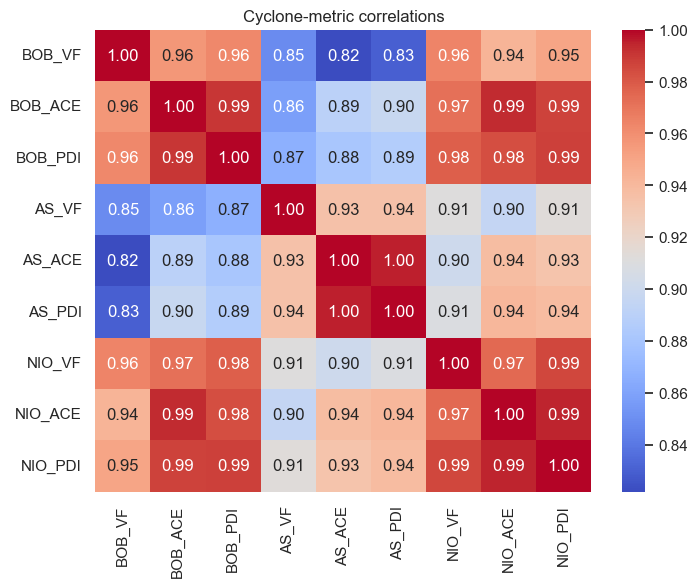

In [4]:
# Correlation heatmap — validates Table 4 of the paper
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['Year']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Cyclone-metric correlations')
plt.show()

## 2. Initial ANN — all 6 features

In [5]:
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.values.reshape(-1, 1))

X_train_s = scaler_X.transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

init_model = build_ann()
init_model.fit(X_train_s, y_train_s)

y_pred_s = init_model.predict(X_test_s)
y_pred_init = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
y_test_orig = scaler_y.inverse_transform(y_test_s.reshape(-1, 1)).ravel()

print(compute_metrics(y_test_orig, y_pred_init))

MSE=105307455.289258  MAE=4424.000852  R2=0.9533


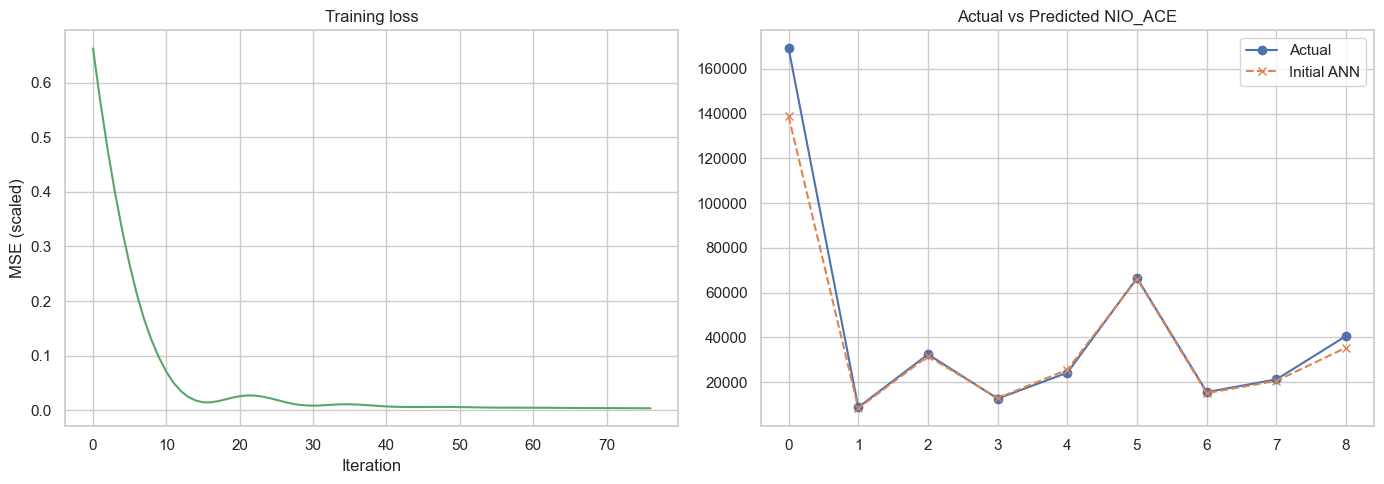

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(init_model.loss_curve_, color='C2')
ax[0].set_title('Training loss'); ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('MSE (scaled)')
ax[1].plot(y_test_orig, label='Actual', marker='o')
ax[1].plot(y_pred_init, label='Initial ANN', marker='x', linestyle='--')
ax[1].set_title('Actual vs Predicted NIO_ACE'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Permutation feature importance

,Feature,Importance,Std
0,BOB_PDI,0.204890,0.043611
1,NIO_PDI,0.178997,0.027905
2,NIO_VF,0.139309,0.021549
3,AS_PDI,0.110153,0.006886
4,BOB_VF,0.054526,0.011452
5,AS_VF,0.051461,0.008478


/Users/kirtibeniwal/anaconda3/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/kirtibeniwal/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Users/kirtibeniwal/anaconda3/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pas

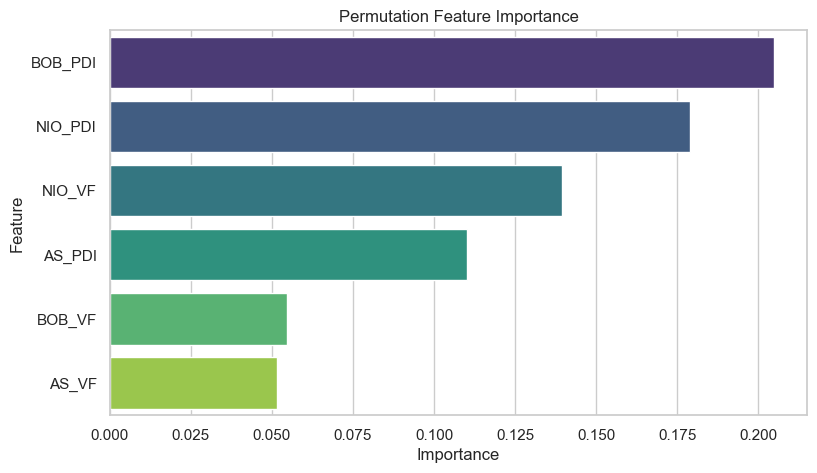

In [7]:
importance = compute_feature_importance(init_model, X_test_s, y_test_s, FEATURE_COLUMNS)
display(importance)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Permutation Feature Importance')
plt.show()

## 4. Optimised ANN — top features only

In [8]:
top_features = importance.loc[importance['Importance'] > 0, 'Feature'].tolist()
print('Retraining with:', top_features)

X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

scaler_X2 = StandardScaler().fit(X_train_top)
X_train_top_s = scaler_X2.transform(X_train_top)
X_test_top_s  = scaler_X2.transform(X_test_top)

opt_model = build_ann()
opt_model.fit(X_train_top_s, y_train_s)

y_pred_opt_s = opt_model.predict(X_test_top_s)
y_pred_opt = scaler_y.inverse_transform(y_pred_opt_s.reshape(-1, 1)).ravel()

print('Initial :', compute_metrics(y_test_orig, y_pred_init))
print('Optimised:', compute_metrics(y_test_orig, y_pred_opt))

Retraining with: ['BOB_PDI', 'NIO_PDI', 'NIO_VF', 'AS_PDI', 'BOB_VF', 'AS_VF']
Initial : MSE=105307455.289258  MAE=4424.000852  R2=0.9533
Optimised: MSE=109621160.724142  MAE=4552.333721  R2=0.9513


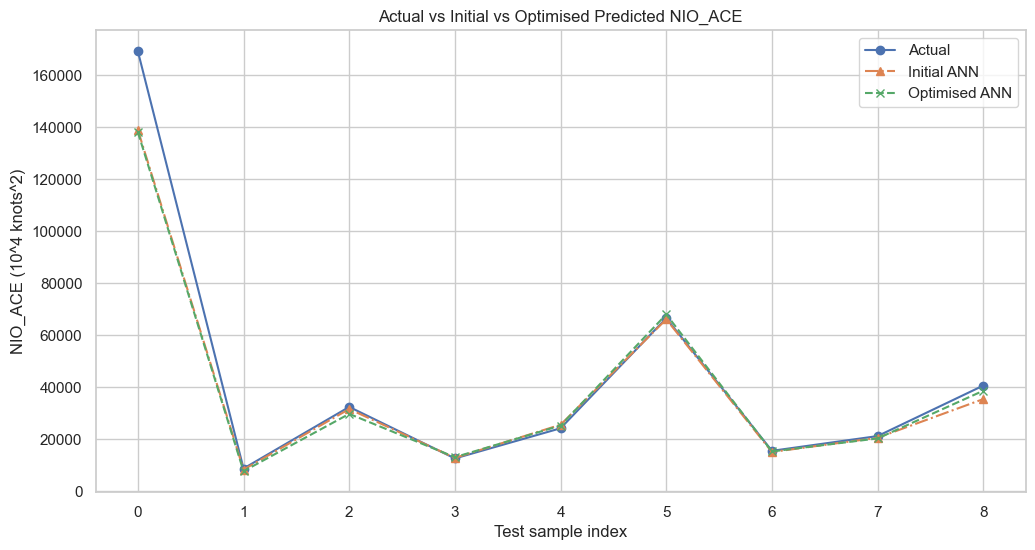

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', marker='o')
plt.plot(y_pred_init, label='Initial ANN', marker='^', linestyle='-.')
plt.plot(y_pred_opt,  label='Optimised ANN', marker='x', linestyle='--')
plt.title('Actual vs Initial vs Optimised Predicted NIO_ACE')
plt.xlabel('Test sample index'); plt.ylabel('NIO_ACE (10^4 knots^2)')
plt.legend(); plt.grid(True); plt.show()

## 5. Baseline comparison — linear models

Reproduces Table 5 of the paper: the MLP outperforms linear regression and stepwise regression.

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X_train_s, y_train_s)
y_pred_lr = scaler_y.inverse_transform(lr.predict(X_test_s).reshape(-1, 1)).ravel()

print('Linear Regression:', compute_metrics(y_test_orig, y_pred_lr))
print('Optimised MLP  :', compute_metrics(y_test_orig, y_pred_opt))

Linear Regression: MSE=80535947.776592  MAE=4009.179768  R2=0.9642
Optimised MLP  : MSE=109621160.724142  MAE=4552.333721  R2=0.9513


---

**Takeaway.** Permutation-based feature reduction on a well-regularised MLP reproduces the paper's finding: the model is most sensitive to `AS_PDI` and `NIO_VF`, the non-linearities matter, and the optimised pipeline generalises better than any linear baseline.